# S01 : From Molecules to Labeled Graphs

## Aim of this talktorial

This talktorial focuses on **molecular representation**: how molecules are encoded, canonicalized, and converted into labeled graphs suitable for downstream graph transformation workflows.

1. A compact **RDKit** tutorial.
2. The **SMILES** string representation and canonicalization.  
3. **Graph representations** that encode molecules as labeled graphs with chemically meaningful node and edge attributes.


This talktorial introduces these pillars with **minimal, explicit implementations** so the underlying assumptions are transparent. We combine:

- **RDKit** as the chemistry reference layer (sanitization, aromaticity, valence semantics) [[1]](#ref-1), and  
- **NetworkX** as a lightweight graph engine for matching, symmetry analysis, and later graph rewriting  [[2]](#ref-2).

The goal is not raw performance but **conceptual clarity**: to expose how choices in labeling and symmetry handling affect downstream tasks such as rule extraction and application in later **SynEdu** notebooks.

---

## Learning outcomes

After completing this talktorial you will be able to:

- Parse SMILES with **RDKit** and understand what sanitization does.  
- Produce canonical SMILES.
- Convert SMILES into **labeled molecular graphs** (atoms → nodes, bonds → edges).  
- Perform a **round-trip conversion** between RDKit and NetworkX and identify which chemical details are preserved or lost.  
- Explain why **symmetry** and **label design** are critical for reaction rule discovery and application.

---

## Outline

- [0. Setup & data](#0-setup--data)
- [1. Introduction to RDKit](#s01-rdkit)
- [2. SMILES](#s01-smiles)
- [3. Molecular Graph representation](#s01-graph)
- [4. Discussion](#s01-discussion)
- [5. Quiz](#s01-quiz)
- [6. References](#s01-references)


## 0. Setup & data

In [1]:
import rdkit
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from synedu.Utils.vis import draw_molecular_graph  # for visualization

print("RDKit version:", rdkit.__version__)
print("NetworkX version:", nx.__version__)

DATA_DIR = Path("data")
CSV_PATH = DATA_DIR / "molecules.csv"
df = pd.read_csv(CSV_PATH)
display(df)

RDKit version: 2025.09.3
NetworkX version: 3.6.1


,smiles,name
0,CCO,ethanol
1,CCCl,chloroethane
2,CCOCC,diethyl ether
3,O,water
4,NCC(=O)O,glycine
...,...,...
995,CNCC(O)c1ccc(O)cc1,oxedrine
996,Cc1nc(Nc2ccc(F)cc2)nc(N2CCc3ccccc3C2C)c1C,revaprazan
997,O=C(O)CCC(=O)c1ccc2c(c1)-c1cccc3cccc-2c13,florantyrone
998,COC(=O)CCC[N+](C)(C)C,carpronium


## 1. Introduction to RDKit

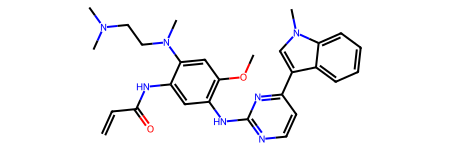

In [2]:
from rdkit import Chem

smiles = "CN1C=C(C2=CC=CC=C21)C3=NC(=NC=C3)NC4=C(C=C(C(=C4)NC(=O)C=C)N(C)CCN(C)C)OC"  # NSCLC TKI
osimertinib = Chem.MolFromSmiles(smiles)
osimertinib  # you can see the figure of osimertinib

Use `IPythonConsole` to render RDKit atom indices on molecular structures.

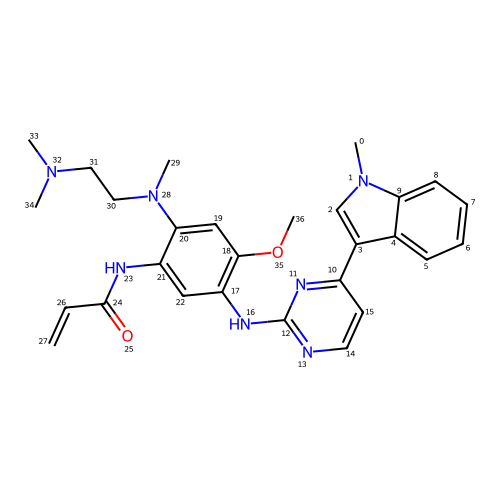

In [3]:
from rdkit.Chem.Draw import IPythonConsole
from typing import Tuple


def set_rdkit_draw_options(
    *,
    atom_indices: bool = True,
    bond_indices: bool = False,
    mol_size: Tuple[int, int] = (500, 500),
):
    """
    Configure RDKit molecule rendering in Jupyter notebooks.

    Parameters
    ----------
    atom_indices : bool, optional
        Whether to display RDKit atom indices (0-based).
    bond_indices : bool, optional
        Whether to display bond indices.
    mol_size : tuple[int, int], optional
        Size of rendered molecule in pixels (width, height).
    """
    IPythonConsole.drawOptions.addAtomIndices = atom_indices
    IPythonConsole.drawOptions.addBondIndices = bond_indices
    IPythonConsole.molSize = mol_size


set_rdkit_draw_options()
osimertinib  # Now you can see the indice of each atom, start from 0

RDKit’s `Draw.MolsToGridImage` allows you to display a list of molecules
as a grid for rapid visual inspection and comparison.

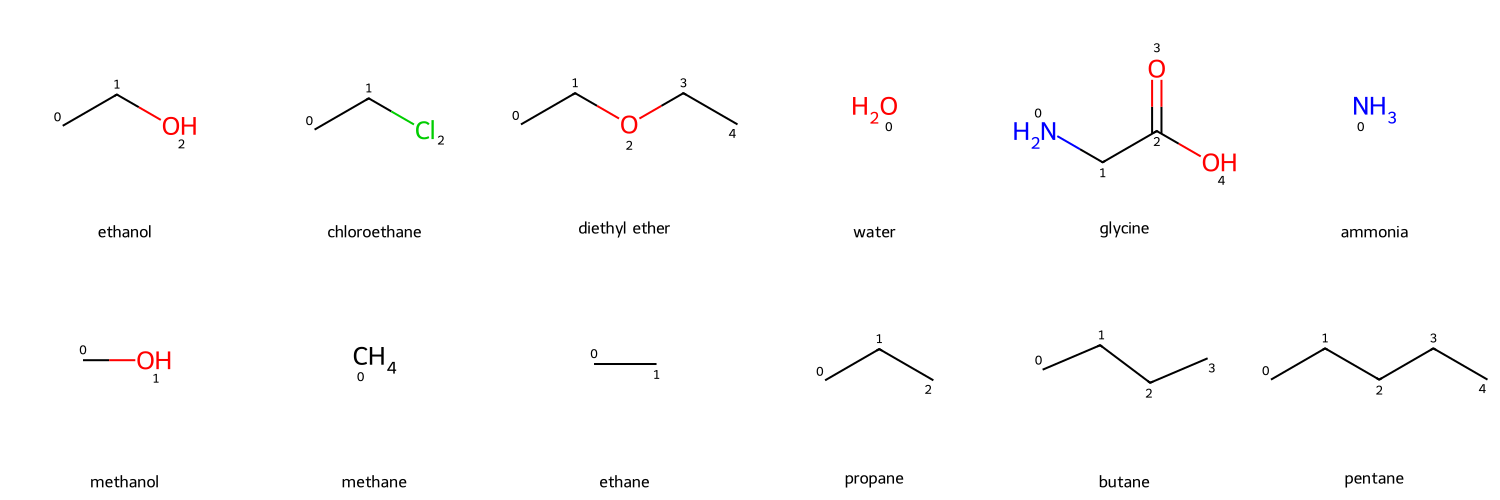

In [4]:
from rdkit.Chem import Draw

some_smiles = df['smiles'][:12].to_list()
legends = df['name'][:12].to_list()
mols = [Chem.MolFromSmiles(x) for x in some_smiles]

Draw.MolsToGridImage(mols, molsPerRow=6, subImgSize=(250, 250), legends=legends)

We now explore basic information encoded in the RDKit representation of osimertinib.

In [5]:
print(osimertinib.GetNumAtoms())  # Number of atoms in osimertinib
print(osimertinib.GetNumBonds())  # Number of bonds in osimertinib

37
40


Using `rdkit.Chem.Descriptors`, we can compute common physicochemical
properties directly from the RDKit molecular representation of osimertinib.

In [6]:
from rdkit.Chem import Descriptors

mw = Descriptors.MolWt(osimertinib)
print(mw)

499.6190000000003


**Q1 — LogP**
 
Compute the octanol–water partition coefficient (logP) of osimertinib using RDKit.

<details> <summary><b>Solution</b></summary>

```python
from rdkit.Chem.Crippen import MolLogP
logp = MolLogP(osimertinib)
```
</details>

In medicinal chemistry, it is important to prioritize the most promising
molecules in order to reduce experimental and computational costs. One of the
simplest and most widely used heuristics for early-stage compound selection is
[Lipinski’s Rule of Five](https://en.wikipedia.org/wiki/Lipinski%27s_rule_of_five),
which describes four physicochemical criteria associated with good oral
bioavailability.

**Lipinski’s Rule of Five**

- No more than 5 hydrogen bond donors (typically N–H or O–H groups).
- No more than 10 hydrogen bond acceptors (primarily nitrogen and oxygen atoms).
- Molecular weight below 500 g/mol.
- logP (octanol–water partition coefficient) below 5.

![Lipinski Rule of Five](figure/RO5.png)

*Figure: Visualization of Lipinski’s Rule of Five describing four physicochemical thresholds associated with oral drug-likeness.*

In [7]:
from rdkit.Chem.Lipinski import NumHAcceptors, NumHDonors

nh_acc = NumHAcceptors(osimertinib)
nh_do = NumHDonors(osimertinib)

**Q2**
 
Compute the number of hydrogen bond donors and acceptors for each molecule in
`mols`.

<details> <summary><b>Solution</b></summary>

```python
from rdkit.Chem.Descriptors import NumHAcceptors, NumHDonors

nh_acc_mols = [NumHAcceptors(mol) for mol in mols]
nh_do_mols  = [NumHDonors(mol) for mol in mols]
```
</details>

We can now use the `Lipinski` function to filter molecules based on
Lipinski’s Rule of Five.

In [8]:
from rdkit.Chem.Crippen import MolLogP


def Lipinski(mol) -> bool:
    """
    Check whether a molecule satisfies Lipinski's Rule of Five.

    Parameters
    ----------
    mol : rdkit.Chem.Mol
        RDKit molecule object.

    Returns
    -------
    bool
        True if the molecule passes all Lipinski criteria, False otherwise.
    """
    if mol is None:
        return False

    mw = Descriptors.MolWt(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)
    logp = MolLogP(mol)

    return mw <= 500 and h_donors <= 5 and h_acceptors <= 10 and logp <= 5


Lipinski(osimertinib)

True

**Q3 — Lipinski filtering**
 
Apply the Lipinski filter to the dataset and annotate the DataFrame with a
pass/fail flag.

<details>
<summary><b>Solution</b></summary>

```python
from rdkit import Chem

df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df["Lipinski"] = df["mol"].apply(passes_lipinski)

```
</details>

## 2. SMILES


SMILES (Simplified Molecular Input Line Entry System) is a compact, human-readable text notation that encodes a molecular **graph** (atoms as nodes, bonds as edges). 


### 2.1. Overview

- SMILES encodes structure with a small set of tokens: atom symbols, bond markers (`=`, `#`), parentheses (branches), digits (ring closures), and `/`/`\` (double-bond geometry).  
- Case matters: uppercase for aliphatic atoms (`C`) and lowercase for aromatic (`c`).  
- Brackets `[...]` are used for explicit hydrogens, isotopes, charges, or uncommon valences.

---

### 2.2. Atoms & bonds

- Atoms by symbol: `C`, `N`, `O`, `Cl`, etc. Implicit hydrogens are assumed by valence rules.  
- Single bonds are usually **implicit**: `CCO` → C–C–O.  
- Double / triple bonds: `C=C`, `C#N`.  
- Brackets for special atoms: `[NH4+]`, `[13C]`, `[O-]`.

**Examples**

```text
C      # methane carbon (implicit H)
CCO    # ethanol fragment (C–C–O)
C=O    # formaldehyde (double bond)
C#N    # hydrogen cyanide (triple bond)
[Na+]  # explicit sodium cation
```

### 2.2 Branches

Parentheses create branches (side chains).

**Examples**

```text
CCO       # linear chain
CC(O)C    # branch: a hydroxyl on the middle carbon
C(C)(C)C  # tert-butyl-like branching
```

### 2.3 Rings

Ring closures use matching digits to connect two positions.

**Examples**

```text
C1CCCCC1   # cyclohexane
c1ccccc1   # benzene (aromatic SMILES)
C1=CC=CC=C1  # alternate (non-aromatic notation)
```

Digits may be combined with `%` for two-digit ring labels (e.g. `C%10CCCCCCCCC%10`).


### 2.4 Aromaticity

- Lowercase letters (e.g., `c`, `n`) commonly mark aromatic atoms.
- Aromatic SMILES implies a specific kekulé/aromatic perception; tools may canonicalize differently.

**Examples**

```text
c1ccccc1   # benzene (aromatic)
n1ccccc1   # pyridine-like aromatic ring
```

### 2.5 Stereochemistry

- Tetrahedral chirality: `@` and `@@` after the chiral atom (relative to atom ordering).
- Double-bond geometry: `/` and `\` indicate relative configuration (E/Z).

**Examples**

```text
C[C@H](O)Cl      # chiral centre (explicit stereochemistry)
C/C=C\C          # defined double-bond geometry
```

RDKit preserves stereochemical flags when you parse and write SMILES with `isomericSmiles=True`.

### 2.6. Bracketed atoms & special cases

Use brackets for:
- explicit hydrogens: `[NH2]`, `[nH]`
- charges: `[O-]`, `[NH4+]`
- isotopes: `[13C]`
- valence exceptions and multi-character element symbols: `[Se]`, `[Cl]`

**Examples**

```text
c1ccccc1[NH2]     # aniline with explicit NH2
c1cc[nH]c1        # aromatic nitrogen with an explicit H (pyrrole-like)
CC(=O)[O-]        # acetate anion
[NH4+]            # ammonium cation
[NH4+].[Cl-]      # ammonium chloride (ionic pair)
[13CH3]C(=O)O     # acetic acid with the methyl carbon labelled 13C
C[Se]C            # dimethyl selenide (Se in brackets)
```

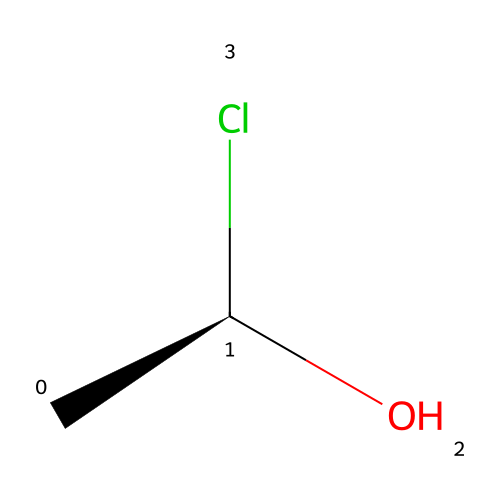

In [9]:
from rdkit import Chem

Chem.MolFromSmiles('C[C@H](O)Cl')

Now experiment with the example from `2.1` to `2.6`

SMILES strings can have many valid variants for the same molecule.

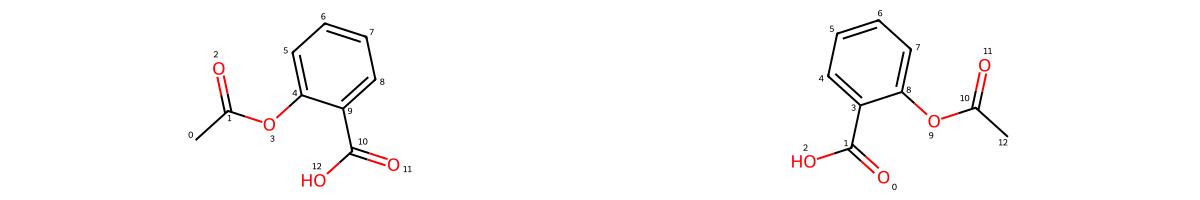

In [10]:
from rdkit.Chem import Draw

s1 = "CC(=O)Oc1ccccc1C(=O)O"
s2 = "O=C(O)c1ccccc1OC(=O)C"

m1 = Chem.MolFromSmiles(s1)
m2 = Chem.MolFromSmiles(s2)

Draw.MolsToGridImage([m1, m2], molsPerRow=2, subImgSize=(600, 200))

The
simplest and most reliable way to compare or normalise SMILES is to convert
them to a **canonical form** in RDKit.

canonical 1: CC(=O)Oc1ccccc1C(=O)O
canonical 2: CC(=O)Oc1ccccc1C(=O)O
same SMILES? True


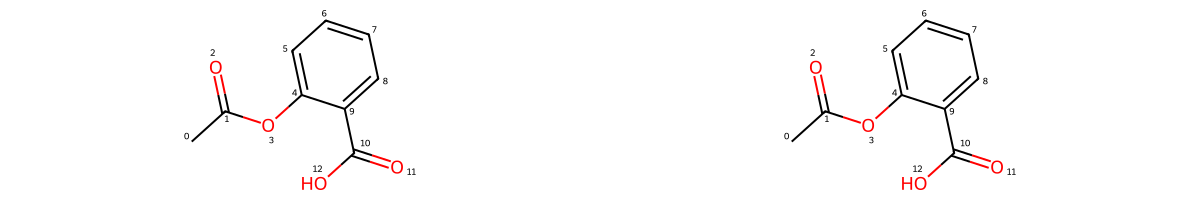

In [11]:
can1 = Chem.CanonSmiles(s1)
can2 = Chem.CanonSmiles(s2)
print("canonical 1:", can1)
print("canonical 2:", can2)
print("same SMILES?", can1 == can2)

m1 = Chem.MolFromSmiles(can1)
m2 = Chem.MolFromSmiles(can2)

Draw.MolsToGridImage([m1, m2], molsPerRow=2, subImgSize=(600, 200))

Graph canonicalization (canonical SMILES, toolkit differences) will be covered in later talktorials.


## 3. Molecular Graph representation

In computational reaction modeling, we represent molecules as **labeled graphs** so that any notion of
“matching” respects **chemical identity**, such as element type, charge, and bond order, rather than bare
connectivity alone.

A **labeled molecular graph** is a quadruple

$$
G = (V, E, a, b),
$$

where:

- **Vertices** $V$ represent **atoms**.
- **Edges** $E \subseteq \{\{u,v\}\mid u,v\in V,\ u\neq v\}$ represent **bonds**
  (finite, undirected, simple: no loops, no parallel edges).
- $a$: atom labelling function.
- $b$: bond labelling function.

We often write $V(G)$ and $E(G)$ for the vertex and edge sets of $G$. For a vertex $v\in V(G)$:

- neighbourhood:
  $$
  N_G(v)=\{w\in V(G)\mid vw\in E(G)\},
  $$
- degree:
  $$
  \deg_G(v)=|N_G(v)|.
  $$

These graph-theoretic notions correspond chemically to an atom’s bonded neighbours and coordination number,
abstracting away geometry while retaining connectivity.

---

### 3.1. Labels and chemical types

“Types” are encoded via explicit labelling maps

$$
\ell_V: V(G)\to L_V,\qquad \ell_E: E(G)\to L_E,
$$

where $L_V$ and $L_E$ are finite, non-empty label sets.
For molecular graphs, we use the chemistry-specific notation:

$$
a_G: V(G)\to L_V \quad\text{(atom labels)},\qquad
b_G: E(G)\to L_E \quad\text{(bond labels)}.
$$

Let $\mathcal{G}$ denote the class of all labelled molecular graphs equipped with $(a_G,b_G)$.
In chemistry, $a_G(v)$ encodes *what atom this is* (element, charge, aromaticity, hydrogen count, …), 
while $b_G(uv)$ encodes *what bond this is* (order, aromaticity, ring status, …).

All subsequent notions of equivalence, symmetry, and matching in this talktorial are defined **relative to these labels**.

---

### 3.2. Graph representations in practice

In SynEdu, **RDKit** and **NetworkX** play complementary roles:

- **RDKit** is the chemical authority: sanitization, valence rules, aromaticity perception, and canonicalization.
- **NetworkX** provides an explicit, inspectable graph representation used for matching, symmetry analysis,
  and later graph rewriting.

To ensure that graph-based operations remain chemically meaningful, we require a **reversible interface**
between the two representations:
a molecule converted from RDKit to a labeled NetworkX graph must be convertible back without loss of
the chemical information encoded in $(a_G,b_G)$.

This reversible interface forms the foundation for all later notions—graph isomorphism, automorphisms,
and eventually reaction rules—introduced in subsequent SynEdu notebooks.


In [12]:
from typing import Dict, Any
import networkx as nx
from rdkit import Chem

In [13]:
def mol_to_graph(mol: Chem.Mol) -> nx.Graph:
    """
    Convert an RDKit Mol to a lightweight heavy-atom NetworkX graph.

    :param mol: Sanitized RDKit molecule.
    :type mol: rdkit.Chem.Mol
    :returns: Graph keyed by atom index.
    :rtype: networkx.Graph
    """
    G = nx.Graph()
    for atom in mol.GetAtoms():
        node_id = atom.GetIdx()
        attrs: Dict[str, Any] = {
            "element": atom.GetSymbol(),
            "formal_charge": int(atom.GetFormalCharge()),
            "aromatic": bool(atom.GetIsAromatic()),
            "hcount": int(atom.GetTotalNumHs()),
        }
        G.add_node(node_id, **attrs)

    for bond in mol.GetBonds():
        u = bond.GetBeginAtomIdx()
        v = bond.GetEndAtomIdx()
        G.add_edge(
            u,
            v,
            order=float(bond.GetBondTypeAsDouble()),
            aromatic=bool(bond.GetIsAromatic()),
        )
    return G

In [14]:
def graph_to_mol(
    G: nx.Graph,
    sanitize: bool = True,
    use_h_count: bool = False,
) -> Chem.Mol:
    """
    Reconstruct an RDKit Mol from a lightweight NetworkX graph.

    :param G: Graph keyed by atom index. Node attrs: ``element`` (str), optional ``formal_charge`` (int),
              optional ``hcount`` (int). Edge attrs: ``order`` (float), optional ``aromatic`` (bool).
    :type G: networkx.Graph
    :param sanitize: If True, sanitize molecule (skips kekulize/set-aromaticity, then calls SetAromaticity).
    :type sanitize: bool
    :param use_h_count: If True, add explicit H atoms according to node ``hcount`` (default: False).
    :type use_h_count: bool
    :returns: Reconstructed RDKit molecule.
    :rtype: rdkit.Chem.Mol
    """
    rw = Chem.RWMol()
    node_to_idx: Dict[Any, int] = {}

    # 1) add heavy atoms (defer aromatic perception)
    for node, data in G.nodes(data=True):
        element = data.get("element", "C")
        charge = int(data.get("formal_charge", 0))
        atom = Chem.Atom(element)
        atom.SetFormalCharge(charge)
        atom.SetIsAromatic(False)
        idx = rw.AddAtom(atom)
        node_to_idx[node] = idx

    # 2) add heavy-heavy bonds
    for u, v, data in G.edges(data=True):
        i = node_to_idx[u]
        j = node_to_idx[v]
        if bool(data.get("aromatic", False)):
            btype = Chem.BondType.AROMATIC
        else:
            try:
                order = int(round(abs(float(data.get("order", 1.0)))))
            except Exception:
                order = 1
            btype = {
                1: Chem.BondType.SINGLE,
                2: Chem.BondType.DOUBLE,
                3: Chem.BondType.TRIPLE,
            }.get(order, Chem.BondType.SINGLE)
        rw.AddBond(i, j, btype)

    # 3) optionally add explicit H atoms
    if use_h_count:
        for node, data in list(G.nodes(data=True)):
            try:
                n_h = int(data.get("hcount", 0))
            except Exception:
                continue
            if n_h <= 0:
                continue
            heavy_idx = node_to_idx[node]
            heavy_atom = rw.GetAtomWithIdx(heavy_idx)
            heavy_atom.SetNoImplicit(True)
            heavy_atom.SetNumExplicitHs(int(n_h))

    mol = rw.GetMol()

    if sanitize:
        Chem.SanitizeMol(
            mol,
            sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL
            ^ Chem.SanitizeFlags.SANITIZE_SETAROMATICITY
            ^ Chem.SanitizeFlags.SANITIZE_KEKULIZE,
        )
        Chem.SetAromaticity(mol)

    return mol

Is consistent: True


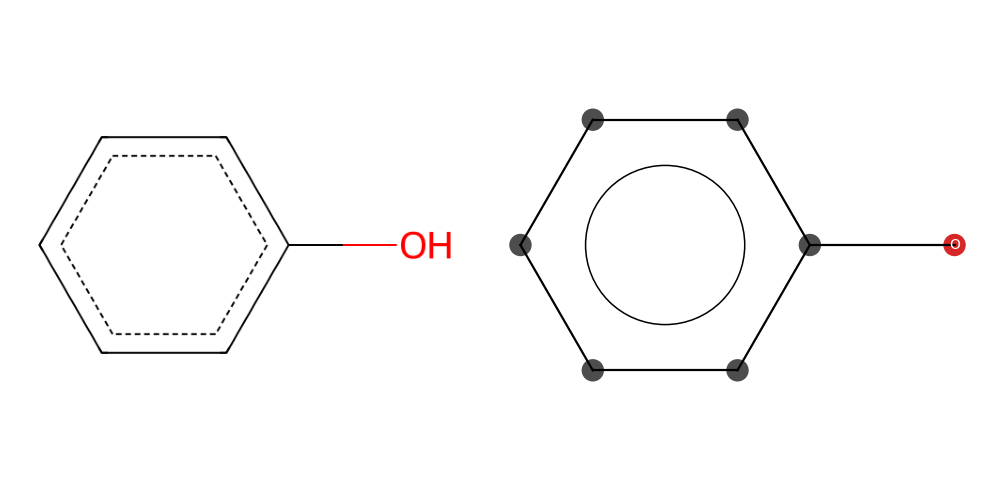

In [15]:
s = Chem.CanonSmiles("c1ccccc1O")
m = Chem.MolFromSmiles(s)
G = mol_to_graph(m)
m1 = graph_to_mol(G)
s1 = Chem.MolToSmiles(m1, canonical=True)
print("Is consistent:", s == s1)

draw_molecular_graph(
    G, mol=m, include_mol=True, label_mode="hetero", aromatic_style="circle"
)
plt.show()

**Q4 — Conversion**

**Goal**
Convert the SMILES below to a graph and back to SMILES.  
Explain **why the round-trip fails**.

```python
smiles = "c1cc[nH]c1"
```

<br>

<details>
<summary><b>Solution</b></summary>

```python
from rdkit import Chem

def naive_roundtrip(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    G = mol_to_graph(mol)
    mol2 = graph_to_mol(G)
    return Chem.MolToSmiles(mol2, canonical=True)

naive_roundtrip("c1cc[nH]c1")
>> 'c1ccnc1'
```
Why it fails

- `[nH]` is an aromatic nitrogen with an **explicit hydrogen**
- **Heavy-atom graphs discard hydrogens**
- RDKit cannot recover this on rebuild: `[nH] → [n]`
- This is **information loss by representation**, not a bug

> **Conclusion:** Heavy-atom graphs are **not information-complete** for SMILES round-trip.


</details> 

Since the hydrogen count is already stored in the graph (`hcount`), it can be
propagated back during molecule reconstruction:

```python
for node, data in G.nodes(data=True):
    n_h = int(data.get("hcount", 0))
    heavy_atom.SetNoImplicit(True)
    heavy_atom.SetNumExplicitHs(n_h)
```
This logic is exposed via:
```python
graph_to_mol(G, use_hcount=True)
```
With `use_hcount=True`, explicit hydrogens (e.g. `[nH]`) are preserved, making the
SMILES round-trip reversible.


In [16]:
from rdkit import Chem


def roundtrip(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    G = mol_to_graph(mol)
    mol2 = graph_to_mol(G, use_h_count=True)
    return Chem.MolToSmiles(mol2, canonical=True)


roundtrip("c1cc[nH]c1")

'c1cc[nH]c1'

**Q5 — Round-trip conversion**

**Goal.** Verify that SMILES in a DataFrame survive a  
SMILES → RDKit → graph → RDKit round-trip **without losing heavy-atom information**.

**Input.** A DataFrame `df` with:
- `smiles`: SMILES string  
- `name`: molecule name  

**Task.**
1. Implement `roundtrip_smiles_equal(smiles)` that:
   - parses a SMILES with RDKit,
   - converts it to a labeled graph (`mol_to_graph`),
   - reconstructs a molecule (`graph_to_mol`),
   - compares **canonical heavy-atom SMILES** (hydrogens removed).
2. Apply it to `df["smiles"]`.
3. Report molecules that fail the round-trip (if any).

---

<details>
<summary><b>Solution</b></summary>

```python
def standardize(smiles):
    return Chem.CanonSmiles(smiles, useChiral=False)


def roundtrip_smiles_equal(smiles: str) -> bool:
    new_smiles = roundtrip(smiles)
    return (
        standardize(new_smiles) == standardize(smiles)) 

df["ok"] = df["smiles"].apply(roundtrip_smiles_equal)
df.loc[~df["ok"], ["name", "smiles"]]
```
</details> 

## 4. Discussion

- A **labeled graph morphism** provides a precise abstraction for
  structure- and attribute-preserving mappings, making the notion of
  “sameness” explicit and inspectable.

- Our **labeled molecular graph** adopts a deliberately minimal attribute
  schema (`symbol`, `formal_charge`, `aromatic`, `order`). This strikes a
  balance between chemical faithfulness and algorithmic tractability:
  too few labels induce spurious symmetries, while too many hinder matching
  and reuse.

- **Round-trip conversion** (RDKit → NetworkX → RDKit) serves as a practical
  validation tool. While exact RDKit internal states need not be preserved,
  maintaining **heavy-atom topology and labels** ensures semantic
  equivalence and reproducibility.

## 5. Quiz

Answer briefly using what you learned about **RDKit**, **SMILES**, and **molecular graphs**.

---

### RDKit
- What is molecule sanitization?
- Why is it needed?

---

### SMILES
- Can one molecule have multiple SMILES?
- What is canonical SMILES and why is it useful?

---

### Molecular graphs
- What do nodes represent?
- What do edges represent?
- Name two atom properties and one bond property used as labels.

---

### Conversion and information loss
- What information is preserved when converting RDKit → NetworkX?
- What information may be lost?
- Why is this acceptable here?

---

## 6. References

1. <a id="ref-1"></a> RDKit documentation: https://www.rdkit.org/docs/  
2. <a id="ref-2"></a> NetworkX documentation: https://networkx.org/documentation/stable/
